# Multilayer Perceptron

## Notebook purpose

This notebook provides complex introduction into MLP *(Multilayer Perceptron)* architecture. The goal is to build a foundation for understanding how they work, necessary for following further concepts and comparasions.

Topics discussed in this work:
- Usefullness of MLP
- Mathematic definitions
- Activation functions
- Gradient calculation 
- Simple network implementation
- Highlights and downsides of MLPs

## MLPs and their use

Multilayer perceptrons are a foundational architecture of modern deep learning, a key branch of AI. Their usefulness in classification and regression tasks is remarkable, particularly when working with structured or tabular data. By stacking layers of neurons, MLPs can learn intricate, non-linear patterns that simpler linear models cannot capture.

However, their performance is not unmatched across all domains. At the end of this notebook as you revise the architecture we will highlight some keypoints and downsides of MLPs.

## Architecture 

This paragraph explains the concepts of MLP network and their architecture. We will also present specific tasks that MLPs are used for and how they impact the architecture. The end of this chapter explains mathematical definitions of network entities as well as whole model.

### Concept and reality

MLP architecture emerged in 1943 and is based on concept of biological neural networks. Network consist of 'neurons', which are mathematical entities that function as fundamental computational units. Inspired by their biological counterparts, these artificial neurons are not living cells but rather simple functions that process information.

<!-- Figure Neuron Diagram -->
<div align="center">
    <figure>
        <img src='./figures/MLP_neuron_CC.png' width=70% alt='Fig1_MLP_Neuron_Concept'>
        <figcaption>
            Fig 1. A diagram illustrating concept of neuron.
            <br>
            <i><a href="https://upload.wikimedia.org/wikipedia/commons/4/44/Neuron3.png">
            Source: wikipedia.org under CC BY-SA 4.0
            </a></i>
        </figcaption>
    </figure>
</div>

These neurons are organized into layers, which function as sequential stages of computation. A typical network consists of an input layer that receives the raw data, one or more hidden layers that perform the intermediate processing, and an output layer that produces the final result.

In a Multilayer Perceptron, these layers are fully connected (or dense), meaning each neuron is connected to every neuron in the next layer. This dense structure allows information to flow forward, ensuring that the output of every neuron contributes to the calculations in the subsequent layer.

<!-- Figure MLP Diagram -->
<div align="center">
    <figure>
        <img src='./figures/MLP_diagram.drawio.png' width=45% alt='Fig2_MLP_Diagram'>
        <figcaption>Fig 2. A diagram illustrating the architecture of a Multilayer Perceptron.</figcaption>
    </figure>
</div>

This hierarchical processing enables the network to learn increasingly complex patterns as data passes through it. The number of neurons in every layer and number of hidden layers can be diffrent *(problem dependent)*. 

The size of the input layer is determined by the number of features in the dataset, with one neuron corresponding to each feature.

On the other hand, the size of the output layer is dictated by the specific task:

- **Binary Classification:** A single neuron is typically used. Its output, usually passed through a sigmoid function, represents the probability of one of the two classes.

- **Multi-Class Classification:** The layer has one neuron for each class. A softmax function is applied to the outputs to create a probability distribution across all classes.

- **Regression:** The number of neurons matches the number of continuous values you want to predict. For example, to predict both the height and weight of a person, you would use two output neurons.

### Mathematical definition

Naming convention:
- $a^{(l)}$ - Any layer with number $l$ (inludes input and output layer).
- $W^{(l)}$ - Weights matrix where $W_{jk}$ represents weight of connection between neuron $k$ from layer $l-1$ and neuron $j$ from layer $l$.
- $b^{(l)}$ - Neuron bias vector in layer $l$.
- $\sigma(\cdot)$ - Activation function (Described in the next chapter).

With above naming convention we can describe MLP layer as follows:

$$
a^{(l)} = \sigma(z^{(l)}) = \sigma(W^{(l)}a^{(l-1)}+b^{(l)})
$$

This equation describes that for each forward to the next layer the activation of each neuron is calculated from linear equation $w\times x + b$. Also additional non-linearity is applied by activation function $\sigma$ which we will take deeper dive into in the next chapter.

The whole MLP network of size $L$ can be denoted as a composition of consecutive layers $a^{(l)}$:

$$
f(x) = a^{(L)} = a^{L} \circ a^{L-1} \circ a^{L-2} \circ \ _\cdots \circ a^{0}
$$

## MLP functions

The core behavior of a Multi-Layer Perceptron (MLP) is defined by two key families of functions: activation functions and loss functions. This chapter will cover the most common and essential functions from both categories.

### Activation Functions

Activation functions are essential part of MLP introducing non-linearity into equation, they decide if the network should be activated and how stron the activation should be. The functions like `sigmoid` or `tanh` can introduce standardization that can make learning process more stable.

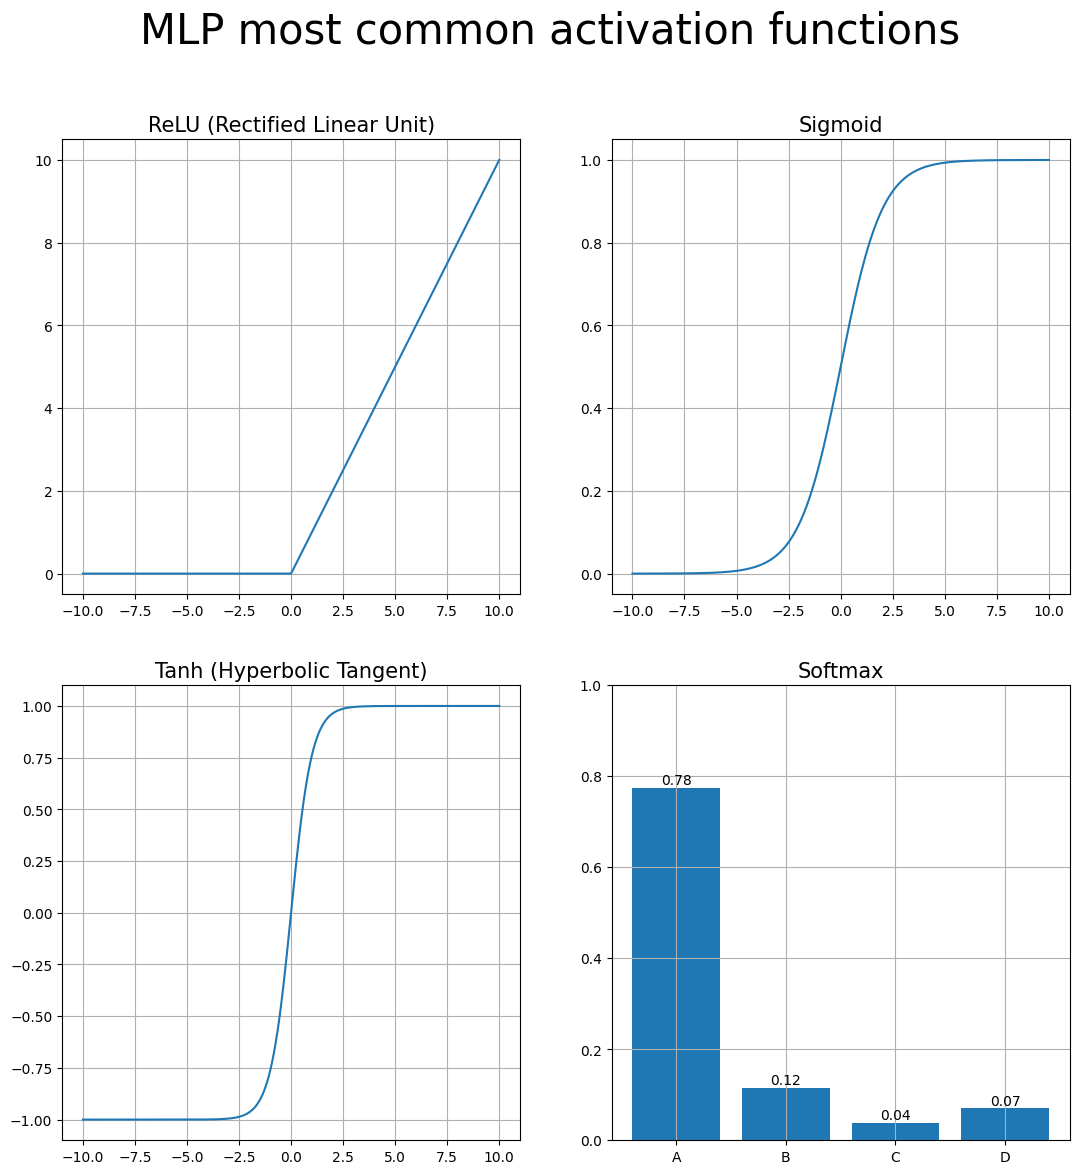

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def relu(x):
    return np.maximum(0,x)

def sigmoid(x):
    return 1/(1 + np.e ** (-x))

def tanh(x):
    e_x = np.e ** x
    e_mx = np.e ** -x
    return (e_x - e_mx)/(e_x + e_mx)

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

x = np.linspace(-10,10,1000)

fig, axes = plt.subplots(2,2, figsize=(13,13))
fig.suptitle('MLP most common activation functions', fontsize=30)

axes[0,0].plot(x, relu(x))
axes[0,0].set_title('ReLU (Rectified Linear Unit)', fontsize=15)
axes[0,1].plot(x, sigmoid(x))
axes[0,1].set_title('Sigmoid', fontsize=15)
axes[1,0].plot(x, tanh(x))
axes[1,0].set_title('Tanh (Hyperbolic Tangent)', fontsize=15)

labels = ['A', 'B', 'C', 'D']
logits = np.array([3.2, 1.3, 0.2, 0.8])
bars = axes[1,1].bar(labels, softmax(logits))
axes[1,1].set_title('Softmax', fontsize=15)
axes[1,1].set_ylim(0,1)
axes[1,1].bar_label(bars, fmt='%.2f')

for ax in axes.flatten():
    ax.grid(True)

plt.show()

<!-- Figure Activation Function Diagrams -->
<div align="center">
    <figure>
        <figcaption>Fig 3. Plots of most popular activation functions.</figcaption>
    </figure>
</div>

The plots of the most common MLP activation functions visualize their distinct mathematical properties and typical roles. The ReLU graph shows a function that is zero for negative inputs and linear for positive ones, reflecting its computational efficiency for hidden layers. The Sigmoid function is displayed as an "S"-shaped curve that squashes values into a (0, 1) range, making it ideal for probabilistic outputs in binary classification. Its zero-centered counterpart, Tanh, shows a similar curve but maps inputs to a (-1, 1) range. Finally, Softmax is uniquely represented as a bar chart to illustrate how it converts a vector of raw scores into a probability distribution where all outputs sum to one, making it essential for multi-class classification.

#### Mathematical definitions

Used convention:
- $\sigma (\cdot)$ - ativation function
- $z$ - neuron logit
- $z_i$ - i-th neuron logit in layer
- $K$ - total number of neurons in layer

Rectified Linear Unit:
$$
\sigma(z) = ReLU(z) = \begin{cases}
    0 & , z < 0 \\
    z & , z \ge 0
\end{cases}
$$

Sigmoid:
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

Hyperbolic Tangent:
$$
\sigma(z) = \text{tanh} \; z = \frac{  e^z-e^{-z}}{e^z+e^{-z}}
$$

Softmax:
$$
\sigma(z) = \text{softmax}(z)_i = \frac{e^{z_i}}{\sum^K_{j=1}e^{z_j}}
$$

### Loss functions

The loss function is a critical component in MLP networks, essential for both evaluating the model and guiding the learning process, which we will discuss in the next chapter. It is crucial to choose a loss function that matches the problem, as an inappropriate choice can lead to unstable training, limit the model's overall effectiveness, or even prevent it from learning from the data altogether. Most common loss functions for diffrent ML tasks are:

- Cross-Entropy (Classification)
- Mean Square Error (Regression)
- Mean Absolute Error (Regression)
- Huber Loss (Regression)



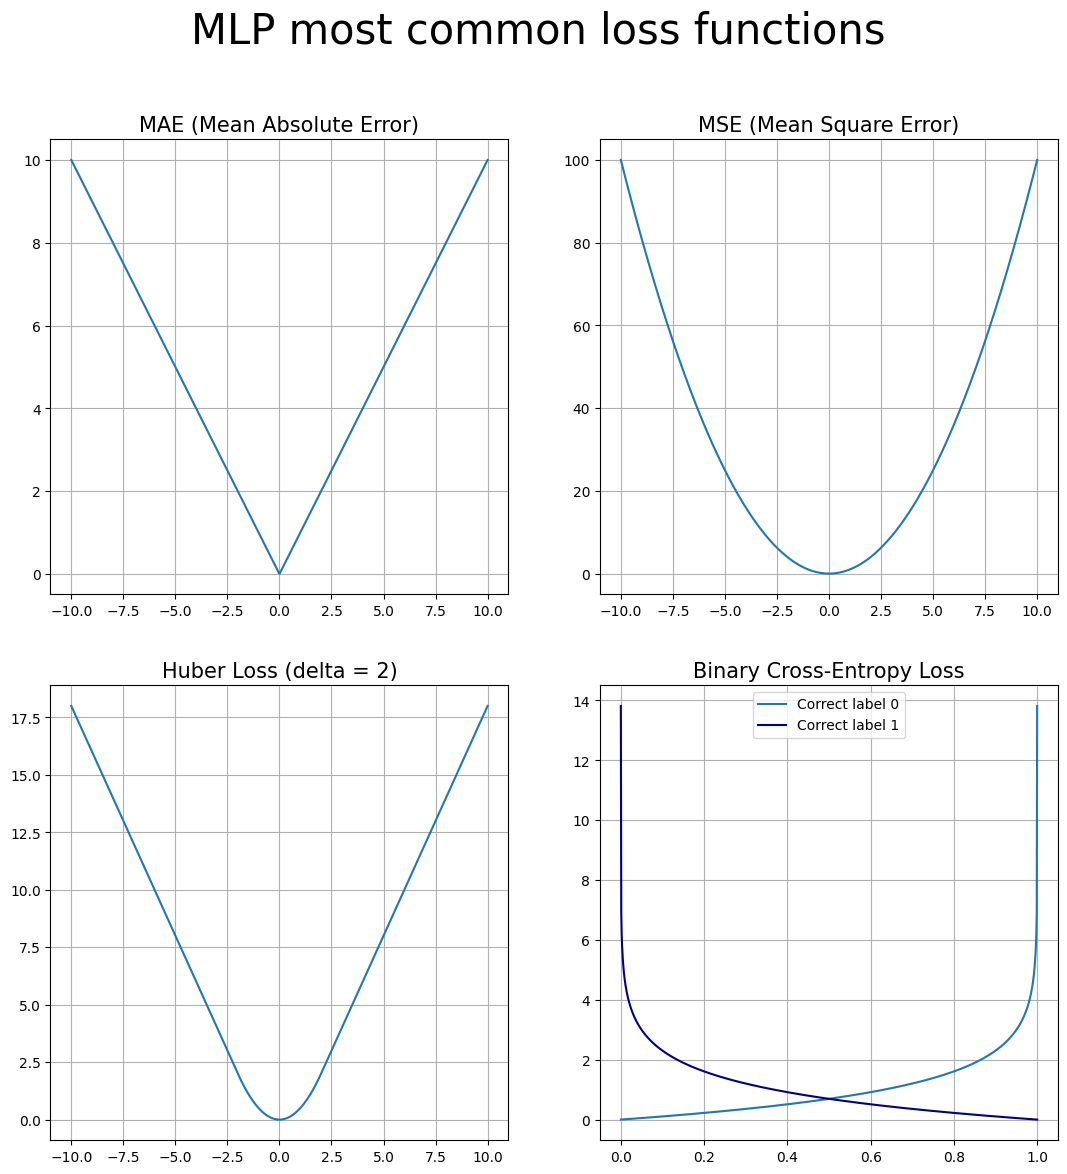

In [11]:
def mae(d):
    return np.abs(d)

def mse(d):
    return (d) ** 2

def huber_loss(d, delta):
    d = np.abs(d)
    return np.where(d > delta, 
        delta * (d - 0.5*delta),    # abs diffrence > delta 
        0.5 * d **2,                # abs diffrence <= delta
    ) 

def bin_cross_entropy_for_true_0(p):
    p = np.where(p==1, 1-10**-6, p)
    return -np.log(1 - p)

def bin_cross_entropy_for_true_1(p):
    p = np.where(p==0, 10**-6, p)
    return -np.log(p)

x = np.linspace(-10,10,1000)

fig, axes = plt.subplots(2,2, figsize=(13,13))
fig.suptitle('MLP most common loss functions', fontsize=30)

axes[0,0].set_title('MAE (Mean Absolute Error)', fontsize=15)
axes[0,0].plot(x, mae(x))

axes[0,1].set_title('MSE (Mean Square Error)', fontsize=15)
axes[0,1].plot(x, mse(x))

axes[1,0].set_title('Huber Loss (delta = 2)', fontsize=15)
axes[1,0].plot(x, huber_loss(x,2))

axes[1,1].set_title('Binary Cross-Entropy Loss', fontsize=15)

p = x / 20 + 0.5
axes[1,1].plot(p, bin_cross_entropy_for_true_0(p), label='Correct label 0')
axes[1,1].plot(p, bin_cross_entropy_for_true_1(p), color='darkblue', label='Correct label 1')
axes[1,1].legend()

for ax in axes.flatten():
    ax.grid(True)

plt.show()

<!-- Figure Loss Function Diagrams -->
<div align="center">
    <figure>
        <figcaption>Fig 4. Plots of most popular loss functions.</figcaption>
    </figure>
</div>

In the visualizations for regression-based loss functions (like MSE, MAE, and Huber), the X-axis denotes the prediction error ($y - \hat{y}$), while the Y-axis represents the calculated loss value, $L(y, \hat{y})$. The shape of these curves reveals their behavior: MSE's parabolic shape shows that it quadratically penalizes large errors, making it highly sensitive to outliers, whereas MAE's V-shape indicates a linear penalty that is more robust.

An exception to this convention is the plot for binary cross-entropy, which is designed for binary classification. For this function, the X-axis indicates the predicted probability of the positive class ('1'). The two distinct curves illustrate the loss for a ground truth label of 1 (dark blue) versus a ground truth label of 0 (light blue). This visualization effectively highlights how the function's penalty grows exponentially as the model becomes more confident in the wrong prediction, driving the learning process.

#### Mathematical definitions

Used notation:
- $L(\cdot)$ - Loss function
- $y$ - true value
- $\hat y$ - predicted value
- $\delta$ - huber loss parameter

Mean Square Error:
$$
L(y,\hat y) = (y-\hat y)^2
$$

Mean Absolute Error:
$$
L(y,\hat y) = |y-\hat y|
$$

Huber Loss:
$$
L(y,\hat y) = \begin{cases}
    \frac{1}{2}(y-\hat y)^2 & , |y-\hat y| \le \delta\\
    \delta(|y-\hat y|-\frac{1}{2}\delta) & , |y-\hat y| > \delta
\end{cases}
$$

For Classification used notation is:
- $L(\cdot)$ - Loss function
- $y_i$ / $y$ - true label
- $\hat y_i$ / $\hat y$ - predicted probability for class
- $C$ - class count

Binary Cross-Entropy:
$$
L = -(y\;log(\hat y) + (1-y)\;log(1-\hat y))
$$

Multi-Class Cross-Entropy:
$$
L = -\sum^C_{i=1}y_i\;log(\hat y_i)
$$



## Learning

This paragraph briefly explains the training cycle for MLP networks and how the backpropagation affects the weights of neurons in model. At the end we will also dive into various optimization techniques used during backward pass and mathematical definition of backpropagation for mini-batch gradient descent.

### Training cycle

MLP learning works by adjusting network weights and biases during backpropagation step of fitting the model. Backpropagation occurs after each batch *(depends on the algorithm chosen)* of data is processed and the loss values are calculated.

<!-- Figure Training Cycle Diagram -->
<div align="center">
    <figure>
        <img src='./figures/MLP_training_cycle.drawio.svg' width=50% alt='Fig1_MLP_Neuron_Concept'>
        <figcaption>
            Fig 5. A diagram presenting MLP training cycle.
        </figcaption>
    </figure>
</div>

Training cycle is divided for 4 consecutive steps:
1. **Forward Pass** - Forward pass starts the training cycle by forewarding the input data *(described in [Architecture](#architecture) chapter)* in a batch through the network. This process outputs the model predictions which are used in the next step.

2. **Loss Calculation** - Given the model outputs from the previous step we calculate the loss values for the whole batch using defined error function *(described in [Error Function](#error-functions-loss-calculation) chapter)*.

3. **Backpropagation (Backward Pass)** - This is the core mechanism of the MLP training process. It efficiently calculates the gradient of the loss function with respect to every weight and bias using calculated loss values. This gradient is then used by the optimization algorithm to adjust the network's parameters, taking a step towards a minimum in the loss function space to reduce the error in subsequent iterations.

4. **Weight Update** - This is the final step in a training iteration, where parameters are updated according to the gradient calculated during backpropagation. The new value is calculated by subtracting the gradient, scaled by the learning rate, from the parameter's current value.

### Optimizers

Optimizers are algorithms used to evaluate the best possible step to find global minimum in the loss function space as quickly as possible. Key parameter of each optimizer is learning rate ($\eta$), which decide the size of the steps we take towards solution. For MLP networks most common optimizers are: Mini-Batch GD, SGD, AdamW or Ranger for advanced optimization. For the purpose of this notebook we will use Mini-Batch Gradient Descent algorithm as a balance between simplicity and effectiveness.

<!-- Figure GD Presentation -->
<div align="center">
    <figure>
        <img src='./figures/MLP_GD.drawio.png' width=50% alt='Fig1_MLP_Neuron_Concept'>
        <figcaption>
            Fig 6. Illustration presenting Mini-Batch Gradien Descent vs Batch Gradient Descent.
        </figcaption>
    </figure>
</div>


Mini-Batch GD works by spliting each batch into mini-batches and updating the model parameters according to learning rate and gradient calculated with respect to each mini-batch. It's much more stable than SGD *(Sochastic Gradient Descent)* and less computationally expensive than normal Batch Gradient Descent giving perfect equilibrium between efectivness and stableness.  

#### Mathematical definition

Unlike Batch Gradient Descent, where the loss function's gradient is computed over the entire dataset, Mini-Batch Gradient Descent involves iteratively calculating the gradient and updating model parameters based on sequentially sampled mini-batches of training data.

Naming convention:
- $\theta$ - parameter of the model (weight and bias).
- $\eta$ - learning rate
- $m$ - mini-batch size
- $J(\theta)$ - loss function
- $\left\{ x^{(i)}, y^{(i)} \right\} ^ m _{i=1}$ - mini-batch with pairs $i = 1,\ _\cdots,m$

First the gradient value is calculated for each mini-batch:
$$
\nabla J \left(\theta\;;\; \left\{ x^{(i)}, y^{(i)} \right\} ^ m _{i=1} \right)
=
\frac{1}{m} \sum^{m}_{i=1} \nabla J \left( \theta\;;\; x^{(i)}, y^{(i)}\right)
$$


Each model parameter will be updated according to the equation:

$$
\theta = \theta - \eta \nabla J \left(\theta\;;\; \left\{ x^{(i)}, y^{(i)} \right\} ^ m _{i=1} \right)
$$

Gradient $\nabla J$ is calculated using Reverse-Mode Automatic Differentiation.

Naming convention:
- $L$ - number of layers (size of network)
- $\sigma(\cdot)^{(l)}$ - activation function for layer l
- $W^{(l)}$ - weight matrix for layer l
- $b^{(l)}$ - bias vector for layer l
- $a^{(l)}$ - activation of neurons in layer l ($a^{(0)}$ - is equivalent to input)
- $J$ - loss value $J(y_{true}\,,y_{pred})$

During forward pass we calculate values *(described in [Architecture Math Definition](#mathematical-definition))*:
$$
z^{(l)} = W^{(l)}a^{(l-1)}+b^{(l)}
$$ 
$$
a^{(l)} = \sigma(z^{(l)})
$$ 

We begin backpropagation by calculating error (loss gradient) for the last layer:
$$
\delta^{(L)}=\frac{\partial J}{\partial a^{(L)}} \odot \sigma _{out} '\left(z^{(L)} \right)
$$
Next step is to calculate gradient for both $W$ and $b$:
$$
\frac{\partial J}{\partial W^{(L)}} = \delta ^{(L)}\left(a^{(L-1)} \right)^{T}
$$
$$
\frac{\partial J}{\partial b^{(L)}} = \delta ^{(L)}
$$
For each next layer we calculate loss gradient by propagating error from previous layer:
$$
\delta^{(L-1)}=\left(\left( W^{(L)} \right)^T \delta^{L}  \right) \odot \sigma _{out} '\left(z^{(L-1)} \right)
$$

$W$ and $b$ gradients equation are analogus for each consecutive layer.

## MLP Implementation

In this chapter, we will dive into a practical implementation of a Multilayer Perceptron (MLP) using Python and NumPy. Our focus will be on building the network from the ground up and training it with a Mini-Batch Gradient Descent (GD) optimizer. To handle the gradient calculations, we'll implement Reverse-Mode Automatic Differentiation, the core mechanism behind backpropagation.

### Utilities

Before implementing the network architecture, we must first define its core components. This section establishes our utility functions, covering the implementation of key activation functions and loss functions. Crucially, we will also implement their respective derivatives, as they are essential for the backpropagation algorithm that enables the network to learn.

In [12]:
#########################################
#       ACTIVATION FUNCTIONS
#########################################

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_prime(x):
    return sigmoid(x)*(1.0 - sigmoid(x))

def relu(x):
    return np.maximum(0, x)

def relu_prime(x):
    return np.where(x > 0, 1, 0)

#########################################
#           LOSS FUNCTIONS
#########################################

def mse(y_true, y_pred):
    return (0.5*(y_true - y_pred)**2).mean()

def mse_prime(y_true, y_pred):
    return y_pred - y_true

def bin_cross_entropy(y_true, y_pred):
    eps = 1e-9
    return -(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

def bin_cross_entropy_prime(y_true, y_pred):
    return -(y_true/y_pred - (1-y_true)/(1-y_pred))

### Activation Layer

This `ActivationLayer` class provides a modular implementation for an activation function within a neural network. During forward propagation, the `forward` method receives input data, stores it for later use, and applies the specified activation function. For backpropagation, the `backward` method calculates the gradient by performing an element-wise multiplication of the incoming `output_error` with the derivative of the activation function, evaluated at the stored input. This result is then passed to the previous layer. Since this layer contains no trainable parameters, the `step` method is empty and performs no action during the weight update phase.

In [13]:
class ActivationLayer:
    def __init__(self, act_func, act_func_prime):
        self.act_func = act_func
        self.act_func_prime = act_func_prime

    def forward(self, input_data):
        self.input = input_data
        return self.act_func(input_data)

    def backward(self, output_error):
        return self.act_func_prime(self.input) * output_error
    
    def step(self, eta):
        return

### Fully Connected Layer

Next step of creating MLP network is implementing fully connected layer logic. We begin by initializing layer with desired `input_size` and `output_size` which are equivalents of neuron counts for consecutive layers in the architecture. Using Reverse-Mode Automatic Differentiation logic we create `forward` and `backward` pass where forward propagation computes neurons linear operation and backward propagation calculates error with respect to previous layers. Last part is the `step` function performing gradient descent update adjusting weights and biases for the whole layer.  

In [14]:
class FullyConnectedLayer:
    def __init__(self, input_size, output_size):
        self.delta_w = np.zeros((input_size, output_size))
        self.delta_b = np.zeros((1,output_size))
        self.passes = 0

        self.weights = np.random.rand(input_size, output_size) - 0.5
        self.bias = np.random.rand(1, output_size) - 0.5

    def forward(self, input_data):
        self.input = input_data
        return np.dot(self.input, self.weights) + self.bias

    def backward(self, output_error):
        input_error = np.dot(output_error, self.weights.T)
        weights_error = np.dot(self.input.reshape(-1, 1), output_error)

        self.delta_w += weights_error
        self.delta_b += output_error
        self.passes += 1
        return input_error

    def step(self, eta):
        self.weights -= eta * self.delta_w / self.passes
        self.bias -= eta * self.delta_b / self.passes

        self.delta_w = np.zeros(self.weights.shape)
        self.delta_b = np.zeros(self.bias.shape)
        self.passes = 0

### Network Class

`Network` class is responsible for combining layers into working MLP, encapsulating learning and prediction processes into `fit` and `predict` functions. Whole process allows for hyperparametrization for learning by introducing key atributes into `fit` function like: `epoches` *(number of iterations for the whole batch)*, `learning_rate` *(fraction of step we take each update)* and `batch_size` *(size of mini-batch after each we upate weights and biases)*. 

In [15]:
class Network:
    def __init__(self, error_func, error_func_prime, verbose=True):
        self.verbose = verbose
        self.layers = []

        self.error_func = error_func
        self.error_func_prime = error_func_prime

    def add(self, layer):
        self.layers.append(layer)

    def predict(self, input_data):
        result = []
        for i in range(input_data.shape[0]):
            output = input_data[i]
            for layer in self.layers:
                output = layer.forward(output)
            result.append(output)
        return result

    def fit(self, x_train, y_train, epoches, learning_rate, batch_size=64):
        for i in range(epoches):
            err = 0

            idx = np.argsort(np.random.random(x_train.shape[0]))[:batch_size]
            x_batch = x_train[idx]
            y_batch = y_train[idx]

            for j in range(batch_size):
                output = x_batch[j]
                for layer in self.layers:
                    output = layer.forward(output)

                err += self.error_func(y_batch[j], output)

                error = self.error_func_prime(y_batch[j], output)
                for layer in reversed(self.layers):
                    error = layer.backward(error)
            
            for layer in self.layers:
                layer.step(learning_rate)

            if (self.verbose) and ((i%10) == 0):
                err /= batch_size
                print('epoch: %5d/%d   error=%0.9f' % (i, epoches, err))

### Test implementation

Now that we have a working MLP network we are going to create a simple scenario to see it in action and evaluate it's usefulness. 


---
**Scenario:**
We want to analyze data from university to understand what factors contribute to students passing a difficult final exam. Lets simulate data for a group of n students. For each student, we record two key features:
- **Grade:** Their current Grade Point Average (GPA), ranging from 2.0 to 5.0.
- **StudyingTime:** The average number of hours they study per week.

In [16]:
# Simulation code
import pandas as pd # Data storing and operations
from sklearn.model_selection import train_test_split # Splitting data into train and test sets 

def simulation(n):
    X = pd.DataFrame(
        {
            'Grade': np.random.normal(3.5, 1, n).round(2).clip(2, 5),
            'StudyingTime': np.random.normal(20, 10, n).round(2).clip(0, None)
        }
    )
    
    y = (
        0.1 
        + 0.4 * (X['Grade'] - 2) / 3
        + 0.4 * (1 / (1 + np.exp((X['StudyingTime'] - 20) / -20)))
    ) > 0.5

    return X, y

# Simulation and data parameters
simulation_data_size = 100000
test_train_split = 0.25

X, y = simulation(simulation_data_size)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_train_split, stratify=y)

Prepared simulation will determines whether a student passes the exam (True) or fails (False). This outcome is probabilistic and influenced by their grades and study time. Out task is to build a machine learning model that can predict whether a student will pass the exam based on their academic and study habits using simulated variables `X_train` and `y_train` for testing followed by `X_test` and `y_test` for evaluation.

---

Let's begin by standardizing data and creating our network and designing the architecture:

In [17]:
# Data standardization
cols = ['Grade', 'StudyingTime']
for col_name in cols:
    mean = X_train[[col_name]].mean()
    std = X_train[[col_name]].std()
    X_train[[col_name]] = (X_train[[col_name]] - mean)/std
    X_test[[col_name]] = (X_test[[col_name]] - mean)/std

# Network architecture
mlp_network = Network(bin_cross_entropy, bin_cross_entropy_prime, verbose=False)

mlp_network.add(FullyConnectedLayer(2, 32))
mlp_network.add(ActivationLayer(relu, relu_prime))
mlp_network.add(FullyConnectedLayer(32,16))
mlp_network.add(ActivationLayer(relu, relu_prime))
mlp_network.add(FullyConnectedLayer(16,4))
mlp_network.add(ActivationLayer(relu, relu_prime))
mlp_network.add(FullyConnectedLayer(4,1))
mlp_network.add(ActivationLayer(sigmoid, sigmoid_prime))

Now we can choose training hyperparameters and test to see if our network pick ups any pattern in data.

In [18]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Training hyperparameters
epoches = 300
learning_rate = 0.032
batch_size = 64

mlp_network.fit(
    X_train.to_numpy(), y_train.to_numpy(),
    epoches=epoches,
    learning_rate=learning_rate,
    batch_size=batch_size
)

pred = mlp_network.predict(X_test.to_numpy())
pred = list(map(lambda x: x[0,0] > 0.5, pred))

# Score results
print(f"Accuracy: {accuracy_score(y_test, pred)}")
print(f"F1: {f1_score(y_test, pred)}")
print(pd.DataFrame(confusion_matrix(y_test, pred)))

Accuracy: 0.99176
F1: 0.9917560429005923
       0      1
0  12403     37
1    169  12391


The results from the simulated environment are highly encouraging and serve as a strong validation of our Multilayer Perceptron (MLP) implementation. We can conclude that the network successfully learned the underlying patterns in the data, demonstrating that its core mechanics—forward propagation, backpropagation, and gradient descent-based updates—are functioning correctly.

## MLP Cons and Pros

The Multilayer Perceptron (MLP) serves as a foundational benchmark in neural networks, representing the archetypal feedforward architecture. Its implementation is notably straightforward, consisting of a simple stack of fully-connected layers, which makes it an excellent model for understanding core deep learning principles. Consequently, it is very easy to build both from scratch and with modern libraries. The MLP's primary strength lies in its application to structured or tabular data, where it effectively handles classification and regression tasks that lack inherent spatial or sequential patterns. Once trained, it is also remarkably fast at making predictions, as inference is little more than a series of optimized matrix operations.

However, the MLP's simplicity is also the source of its most significant limitations. Its core weakness is a complete lack of awareness for any inherent structure in the input data. By treating all inputs as flat vectors, it fails to recognize the spatial relationships in an image or the temporal order in a sentence, rendering it unsuitable for such tasks. This architectural design also leads to severe parameter inefficiency. With every neuron connected to every other in adjacent layers, the number of weights grows exponentially with high-dimensional inputs, making the model slow to train, memory-intensive, and highly susceptible to overfitting. Unlike more advanced architectures, the MLP cannot perform automatic feature extraction, meaning its performance is heavily dependent on the quality of pre-engineered features.